### Strategy 1st try 

Investment horizon : 5 days 

Strategy 1: 
Compare predicted volatility to avg. volatility 
Open Butterfly long if pred_vol < avg_vol

Strategy 2: 
Compare predicted volatility to implied volatility
Open Butterfly long if pred_vol < IV





In [3]:
# %pip install py_vollib

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from py_vollib.black_scholes import black_scholes
from scipy.stats import percentileofscore
from datetime import datetime
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import yfinance as yf
from py_vollib.black_scholes import implied_volatility

#### Data import 

In [3]:
# Underlying 

### !!!!!!!!!!! YF not working anymore? 


SPX_data = yf.download("^SPX", start="2024-01-19", interval="1d")[['Close']].rename(columns={'Close': 'SP500'})
SPX_data.columns = SPX_data.columns.get_level_values(-1)
SPX_data= SPX_data.reset_index()

SPX_data = SPX_data.rename(columns={'Date': 'timestamp', '^SPX': 'close'})
SPX_data["timestamp"] = pd.to_datetime(SPX_data["timestamp"])

#filter 
start_date = '2024-01-19'
end_date = '2025-01-17'

spx_data = SPX_data[(SPX_data['timestamp'] >= start_date) & (SPX_data['timestamp'] <= end_date)]
spx_data['timestamp'] = spx_data['timestamp'].dt.tz_localize('UTC')



[*********************100%%**********************]  1 of 1 completed

1 Failed download:
['^SPX']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


In [11]:
path = r"C:\Users\pauli\Downloads\Download Data - FUND_US_ARCX_SPY.csv"   #1Y data from Market watch 

underlying_data = pd.read_csv(path)

options_data = pd.read_csv(r"C:\Users\pauli\Butterflies-\options\options.csv")
options_data


,Unnamed: 0,symbol,timestamp,close,volume,trade_count,vwap,expiration_date,strike_price,size,type,style,open_interest,open_interest_date,close_price,close_price_date,SPY_close_days_before,SPY_close
0,0,SPY240308C00480000,2024-03-01 05:00:00+00:00,33.37,24.0,14.0,32.372083,2024-03-08,480.0,100,call,american,274.0,2024-03-07,35.23,2024-03-07,504.836121,503.723846
1,1,SPY240308C00480000,2024-03-04 05:00:00+00:00,33.46,1.0,1.0,33.460000,2024-03-08,480.0,100,call,american,274.0,2024-03-07,35.23,2024-03-07,504.836121,503.723846
2,2,SPY240308C00480000,2024-03-05 05:00:00+00:00,26.42,24.0,8.0,27.284583,2024-03-08,480.0,100,call,american,274.0,2024-03-07,35.23,2024-03-07,504.836121,503.723846
3,3,SPY240308C00480000,2024-03-06 05:00:00+00:00,30.50,32.0,5.0,31.232500,2024-03-08,480.0,100,call,american,274.0,2024-03-07,35.23,2024-03-07,504.836121,503.723846
4,4,SPY240308C00480000,2024-03-07 05:00:00+00:00,35.23,136.0,13.0,35.039485,2024-03-08,480.0,100,call,american,274.0,2024-03-07,35.23,2024-03-07,504.836121,503.723846
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145454,1,SPY250428P00539000,2025-04-22 04:00:00+00:00,14.09,563.0,22.0,13.869947,2025-04-28,539.0,100,put,american,2321.0,2025-04-25,0.01,2025-04-28,513.880005,550.849976
145455,2,SPY250428P00539000,2025-04-23 04:00:00+00:00,8.18,1652.0,372.0,6.807906,2025-04-28,539.0,100,put,american,2321.0,2025-04-25,0.01,2025-04-28,513.880005,550.849976
145456,3,SPY250428P00539000,2025-04-24 04:00:00+00:00,2.13,3034.0,746.0,3.800247,2025-04-28,539.0,100,put,american,2321.0,2025-04-25,0.01,2025-04-28,513.880005,550.849976
145457,4,SPY250428P00539000,2025-04-25 04:00:00+00:00,0.52,9768.0,2112.0,1.158611,2025-04-28,539.0,100,put,american,2321.0,2025-04-25,0.01,2025-04-28,513.880005,550.849976


In [12]:
import datetime as dt
import pytz

options_data['expiration_date'] = pd.to_datetime(options_data['expiration_date'])
options_data['timestamp'] = pd.to_datetime(options_data['timestamp'])
options_data["open_interest_date"] = pd.to_datetime(options_data["open_interest_date"])
options_data["close_price_date"] = pd.to_datetime(options_data["close_price_date"])

# add UTC to timestamps 

options_data['expiration_date'] = options_data['expiration_date'].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

options_data["close_price_date"] = options_data["close_price_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)

options_data["open_interest_date"] = options_data["open_interest_date"].apply(
    lambda d: pd.Timestamp(dt.datetime.combine(d.date(), dt.time(5, 0))).tz_localize('UTC')
)


# calculate dtm 
options_data['dtm'] = options_data.apply(
    lambda row: np.busday_count(row['timestamp'].date(), row['expiration_date'].date()),
    axis=1
)    #trading_days_to_expiry

#options_data["dtm"] = (options_data['expiration_date'] - options_data['timestamp']).dt.days
options_data.head(10)

# columns to add: days to expiry dte, IV, avg_50d_vol, 


,Unnamed: 0,symbol,timestamp,close,volume,trade_count,vwap,expiration_date,strike_price,size,type,style,open_interest,open_interest_date,close_price,close_price_date,SPY_close_days_before,SPY_close,dtm
0,0,SPY240308C00480000,2024-03-01 05:00:00+00:00,33.37,24.0,14.0,32.372083,2024-03-08 05:00:00+00:00,480.0,100,call,american,274.0,2024-03-07 05:00:00+00:00,35.23,2024-03-07 05:00:00+00:00,504.836121,503.723846,5
1,1,SPY240308C00480000,2024-03-04 05:00:00+00:00,33.46,1.0,1.0,33.460000,2024-03-08 05:00:00+00:00,480.0,100,call,american,274.0,2024-03-07 05:00:00+00:00,35.23,2024-03-07 05:00:00+00:00,504.836121,503.723846,4
2,2,SPY240308C00480000,2024-03-05 05:00:00+00:00,26.42,24.0,8.0,27.284583,2024-03-08 05:00:00+00:00,480.0,100,call,american,274.0,2024-03-07 05:00:00+00:00,35.23,2024-03-07 05:00:00+00:00,504.836121,503.723846,3
3,3,SPY240308C00480000,2024-03-06 05:00:00+00:00,30.50,32.0,5.0,31.232500,2024-03-08 05:00:00+00:00,480.0,100,call,american,274.0,2024-03-07 05:00:00+00:00,35.23,2024-03-07 05:00:00+00:00,504.836121,503.723846,2
4,4,SPY240308C00480000,2024-03-07 05:00:00+00:00,35.23,136.0,13.0,35.039485,2024-03-08 05:00:00+00:00,480.0,100,call,american,274.0,2024-03-07 05:00:00+00:00,35.23,2024-03-07 05:00:00+00:00,504.836121,503.723846,1
5,5,SPY240308C00480000,2024-03-08 05:00:00+00:00,32.64,187.0,23.0,34.382941,2024-03-08 05:00:00+00:00,480.0,100,call,american,274.0,2024-03-07 05:00:00+00:00,35.23,2024-03-07 05:00:00+00:00,504.836121,503.723846,0
6,0,SPY240308C00481000,2024-03-01 05:00:00+00:00,32.32,6.0,6.0,31.140000,2024-03-08 05:00:00+00:00,481.0,100,call,american,285.0,2024-03-07 05:00:00+00:00,34.50,2024-03-07 05:00:00+00:00,504.836121,503.723846,5
7,1,SPY240308C00481000,2024-03-04 05:00:00+00:00,33.23,7.0,2.0,33.252857,2024-03-08 05:00:00+00:00,481.0,100,call,american,285.0,2024-03-07 05:00:00+00:00,34.50,2024-03-07 05:00:00+00:00,504.836121,503.723846,4
8,2,SPY240308C00481000,2024-03-05 05:00:00+00:00,25.18,4.0,4.0,26.837500,2024-03-08 05:00:00+00:00,481.0,100,call,american,285.0,2024-03-07 05:00:00+00:00,34.50,2024-03-07 05:00:00+00:00,504.836121,503.723846,3
9,3,SPY240308C00481000,2024-03-06 05:00:00+00:00,28.70,1.0,1.0,28.700000,2024-03-08 05:00:00+00:00,481.0,100,call,american,285.0,2024-03-07 05:00:00+00:00,34.50,2024-03-07 05:00:00+00:00,504.836121,503.723846,2


In [7]:
options_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145459 entries, 0 to 145458
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype              
---  ------                 --------------   -----              
 0   Unnamed: 0             145459 non-null  int64              
 1   symbol                 145459 non-null  object             
 2   timestamp              145459 non-null  datetime64[ns, UTC]
 3   close                  145459 non-null  float64            
 4   volume                 145459 non-null  float64            
 5   trade_count            145459 non-null  float64            
 6   vwap                   145459 non-null  float64            
 7   expiration_date        145459 non-null  datetime64[ns, UTC]
 8   strike_price           145459 non-null  float64            
 9   size                   145459 non-null  int64              
 10  type                   145459 non-null  object             
 11  style                  145459 non-null 

In [ ]:
# investment strategy 



# for each day calculate the 50 day avg volatility
def calculate_avg_volatility(underlying_data): 
    # ------------------
    # implement 
    # ------------------
    return avg_volatility


def select_available_options(options_data, invest_day=datetime):

    options_available = []

    if options_data["timestamp"] = invest_day and options_data["expiration_date"] = invest_day + 5 


    return 




for day in options_data["timestamp"]: #look at all the options available one day that expire 5 days from now
    # compare 

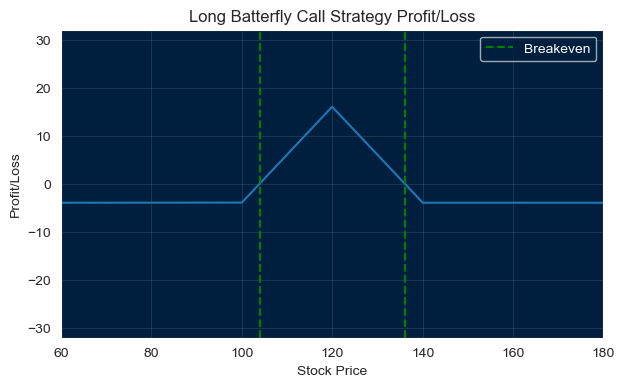

Net Cost/Credit: -3.9593731000237256
Profit if price will be between 103.95844395844395 and 136.04155604155605
Loss if price will be lower than 103.95844395844395 or higher than 136.04155604155605


In [ ]:
#------------------------------------------------
# # play with option strategy 
#-----------------------------------------------
from OptionStrategyfunctions import OptionStrategy

# OptionStrategy(Price_underlying,risk_free_rate = , days_to_maturity)


option = OptionStrategy(80,0.1,2)
sigma = 0.189 # adapt as dynamic rolling window (90 days?) 

option.long_butterfly_call(sigma, 100, 120, 140)

